 # Question 1: Wage discrimination in starting salaries
 Does wage discrimination exist in the starting salaries of faculty members (i.e., salaries in the year hired)?

In [50]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm
import matplotlib.pyplot as plt
import plotly.express as px
import numpy as np
import scipy.stats as stats
import scipy.stats as ttest_ind
import warnings
warnings.filterwarnings('ignore')
pd.options.mode.chained_assignment = None
salaries = pd.read_csv("salary.txt", sep=r"\s+")

In [2]:
#Filtering out starting salaries 
starting_salaries = salaries[salaries["year"] == salaries["startyr"]].copy()

[]

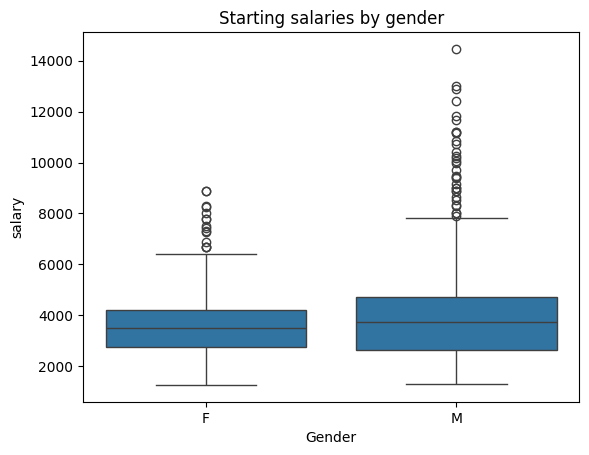

In [3]:
# Generally plotting salaries for each sex to see if there is an observable difference.
sns.boxplot(data = starting_salaries, x = "sex", y ="salary")
plt.xlabel("Gender")
plt.title ("Starting salaries by gender")
plt.plot()

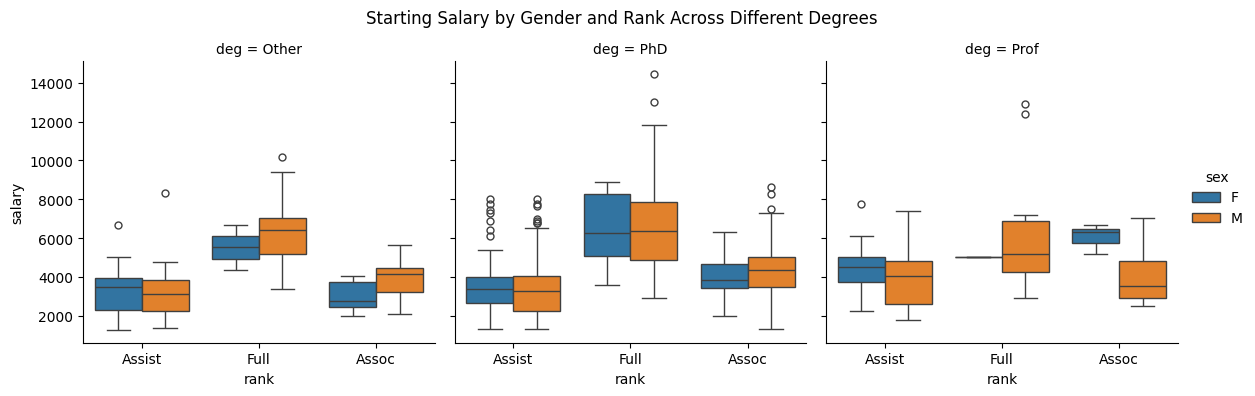

In [4]:
#Now doing some data exploration to observe for any patterns in the data before we start using numerical methos.
g = sns.catplot(
    data=starting_salaries,
    x="rank",
    y="salary",
    col="deg",
    hue="sex",
    kind="box",
    height=4,
    aspect=1
)

g.fig.suptitle("Starting Salary by Gender and Rank Across Different Degrees")

g.fig.subplots_adjust(top=0.85)  # pushes plots down

plt.show()

Now since generally one's years since their highest degree which can also be years they might have been in the industry might affect their starting salary, we can create a new field called "years_since_degree" to see if there is any observable pattern between experience and starting salary
This field is to help observe any patterns between time spent before being hired, starting salary, and sex.

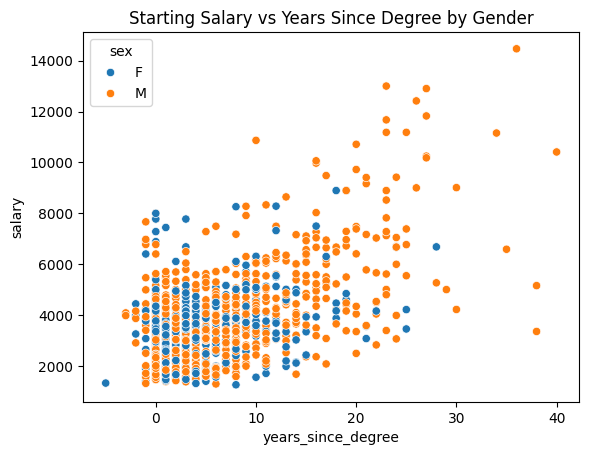

In [5]:
starting_salaries["years_since_degree"] = starting_salaries["startyr"] - starting_salaries["yrdeg"]
sns.scatterplot(data = starting_salaries, x = "years_since_degree", y = "salary", hue = "sex")
plt.title("Starting Salary vs Years Since Degree by Gender")  # <-- set title here
plt.show()

## 2. Numerical summaries

In [ ]:
# Getting numeric summary statistics for salaries by sex
starting_salary_summary = starting_salaries.groupby("sex").agg(
    median_salary=("salary", "median"),
    mean_salary=("salary", "mean"),
    count=("salary", "count")
).reset_index() 
print (starting_salary_summary)

starting_salary_melted = starting_salary_summary.melt(
    id_vars='sex', 
    value_vars=['median_salary', 'mean_salary'], 
    var_name='statistic', 
    value_name='salary'
)

sns.barplot(data=starting_salary_melted, x='sex', y='salary', hue='statistic', palette=['green','red'])
plt.title("Mean and Median Starting Salary by Gender")
plt.ylabel("Salary")
plt.xlabel("Gender")
plt.show()

Checking for correlation between gender and starting salary.

In [6]:
starting_salaries['sex_numeric'] = starting_salaries['sex'].map({'F': 0, 'M': 1}) 
correlation = starting_salaries['salary'].corr(starting_salaries['sex_numeric']) 
print("Correlation between starting salary and gender:", correlation)


Correlation between starting salary and gender: 0.10901192566702962


After checking for correlation between gender and starting salary, we observe that there is a very weak positive of 0.1 association between gender and starting salary, with males earning more on average.

## 3. Statistical Methods

Now that we have an idea of the data, we can start statistically assessing the data.

First we will use a multiple linear regression model predicting salary from sex, field, degree, experience, rank, and admin.

In [77]:
model = smf.ols(
    "salary ~ sex + field + deg + years_since_degree + rank + admin",
    data=starting_salaries
).fit()

# 1. Map to Human-Readable Labels for the Executive Report
name_map_start = {
    'Intercept': 'Baseline Constant',
    'sex[T.M]': 'Sex: Male (Ref: Female)',
    'field[T.Other]': 'Field: Other',
    'field[T.Prof]': 'Field: Professional',
    'deg[T.PhD]': 'Degree: PhD',
    'deg[T.Prof]': 'Degree: Professional',
    'rank[T.Assoc]': 'Rank: Associate Professor',
    'rank[T.Full]': 'Rank: Full Professor',
    'years_since_degree': 'Years Since Degree',
    'admin': 'Administrative Duties'
}

# 2. Extract results and map names
results_start = pd.DataFrame({
    'Variable': model.model.exog_names,
    'Coefficient': model.params.values,
    'Std. Error': model.bse.values,
    'P-Value': model.pvalues.values
})
results_start['Variable'] = results_start['Variable'].map(name_map_start).fillna(results_start['Variable'])

# 3. Sort by P-Value (Ascending)
results_start_sorted = results_start.sort_values(by="P-Value", ascending=True)

# 4. Generate Styled HTML
styled_start_table = (results_start_sorted.style
    .format({
        'Coefficient': '${:,.2f}',
        'Std. Error': '{:.2f}',
        'P-Value': '{:.4f}'
    })
    # Apply light red/pink highlighting to the 'Sex: Male' row specifically if it's significant
    .apply(lambda x: ['background-color: #f8d7da' if 'Sex: Male' in str(x['Variable']) and x['P-Value'] < 0.05 else '' for _ in x], axis=1)
    # Apply light green to all other significant rows
    .apply(lambda x: ['background-color: #e6ffed' if 'Sex: Male' not in str(x['Variable']) and x['P-Value'] < 0.05 else '' for _ in x], axis=1)
    .set_caption("<b>Table 1: Regression Analysis of Starting Salary Determinants (Sorted by Significance)</b>")
    .set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#343a40'), ('color', 'white'), ('font-weight', 'bold'), ('border', '1px solid #ccc')]},
        {'selector': 'td', 'props': [('border', '1px solid #eee'), ('padding', '10px')]},
        {'selector': 'caption', 'props': [('font-size', '1.25em'), ('margin-bottom', '10px'), ('text-align', 'left')]}
    ])
    .hide(axis='index')
)

styled_start_table

Variable,Coefficient,Std. Error,P-Value
Baseline Constant,"$2,378.99",175.75,0.0000
Rank: Full Professor,"$2,134.69",199.80,0.0000
Years Since Degree,$70.37,9.45,0.0000
Field: Professional,$859.93,156.18,0.0000
Field: Other,$469.38,131.68,0.0004
Rank: Associate Professor,$389.62,132.50,0.0033
Degree: PhD,$385.28,155.14,0.0132
Degree: Professional,$508.41,222.32,0.0224
Sex: Male (Ref: Female),$-147.11,94.01,0.1179
Administrative Duties,$31.11,225.96,0.8905


From the above we observe that statistically significant predictors are Statistically significant predictors are rank, experience, and field.

Next we use ANOVA to also test whether removing sex would affect the model.

In [9]:
# Test removing gender
model_full = smf.ols(
    "salary ~ sex + field + deg + years_since_degree + rank + admin",
    data=starting_salaries
).fit()

model_reduced_gender = smf.ols(
    "salary ~ field + deg + years_since_degree + rank + admin",
    data=starting_salaries
).fit()

anova_lm(model_reduced_gender, model_full)

,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,1098.0,2.144679e+09,0.0,NaN,NaN,NaN
1,1097.0,2.139902e+09,1.0,4.777297e+06,2.449035,0.117886


From the above we observe a p value of 0.118 which means that removing gender would not significantly affect starting salaries, if we assume an non interactive model.

Next we will create an interactive model to see if there are any interactions between the predictors and gender.

This can help us observe if their are any interaction with gender that might point to starting salary discrimation by gender.

In [75]:
#Interactive model

model2 = smf.ols(
    "salary ~ sex * (field + deg + years_since_degree + rank)",
    data=starting_salaries
).fit()

# Extracting coefficients table
results_df = pd.DataFrame({
    "coef": model2.params,
    "p_value": model2.pvalues,
    "t_value": model2.tvalues
})

# Sorting by p-value ascending to see if there is any sex interaction that is significant
results_df_sorted = results_df.sort_values(by="p_value", ascending=True)

# 1. Map to Human-Readable Labels
name_map = {
    'Intercept': 'Baseline Constant',
    'C(sex)[T.M]': 'Sex: Male (Ref: Female)',
    'C(field)[T.Other]': 'Field: Other',
    'C(field)[T.Prof]': 'Field: Professional',
    'C(deg)[T.PhD]': 'Degree: PhD',
    'C(deg)[T.Prof]': 'Degree: Professional',
    'yrdeg': 'Year of Degree',
    'admin': 'Administrative Duties',
    'years_since_degree': 'Years Since Degree',
    'years_at_inst': 'Years at Institution'
}

# 2. Prepare the DataFrame for the HTML view
# Resetting index turns the variable names into a styleable column
results_final = results_df.copy().reset_index()
results_final.rename(columns={'index': 'Variable'}, inplace=True)
results_final['Variable'] = results_final['Variable'].map(name_map).fillna(results_final['Variable'])

# 3. Sort by p_value (Ascending)
results_final = results_final.sort_values(by="p_value", ascending=True)

# 4. Generate Styled HTML
styled_table = (results_final.style
    .format({
        'coef': '{:.4f}',
        'p_value': '{:.4f}',
        't_value': '{:.2f}'
    })
    # Apply light green highlighting to significant rows (p < 0.05)
    .apply(lambda x: ['background-color: #e6ffed' if x['p_value'] < 0.05 else '' for _ in x], axis=1)
    # Add a bold border to separate the Variable names
    .set_properties(subset=['Variable'], **{'font-weight': 'bold', 'border-right': '1px solid #ccc'})
    .set_caption("<b>Table 2: Significant Predictors of Promotion Salary Increase (Sorted by P-Value)</b>")
    .set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#f8f9fa'), ('color', '#333'), ('border', '1px solid #ccc'), ('padding', '12px')]},
        {'selector': 'td', 'props': [('border', '1px solid #eee'), ('padding', '10px')]},
        {'selector': 'caption', 'props': [('font-size', '1.25em'), ('margin-bottom', '10px'), ('text-align', 'left')]}
    ])
    .hide(axis='index')
)

styled_table

Variable,coef,p_value,t_value
Baseline Constant,2767.7577,0.0000,10.54
rank[T.Full],2514.0800,0.0000,5.99
field[T.Prof],1059.4832,0.0004,3.54
sex[T.M]:years_since_degree,73.5542,0.0005,3.49
deg[T.Prof],1060.8552,0.0095,2.60
field[T.Other],403.5185,0.0359,2.10
sex[T.M],-679.9913,0.0517,-1.95
rank[T.Assoc],449.4094,0.0911,1.69
sex[T.M]:deg[T.Prof],-748.2440,0.1276,-1.52
sex[T.M]:rank[T.Full],-623.1070,0.1880,-1.32


We then observe that is only significant when there is experience (5.070323e-04) 

We then observe that there is relevance gender almost insignificant with p value of 0.0517 but close eniugh to be considerable.

Therefore we will analyse using permutations to see if we randomly assign gender, whether we observe that it is by chance that the observed differences in starting salary are by chance. 

The null hypothesis we will be testing for, is that there is no difference between males and females starting salaries

In [11]:
#Observed difference in means (M - F)
obs_diff = (
    starting_salaries[starting_salaries["sex"] == "M"]["salary"].mean()
    - starting_salaries[starting_salaries["sex"] == "F"]["salary"].mean()
)

print(obs_diff)

415.22248665226107


In [12]:
# Permutation test
np.random.seed(123)

perm_diffs = []

for _ in range(5000):
    shuffled_sex = np.random.permutation(starting_salaries["sex"])
    
    diff = (
        starting_salaries["salary"][shuffled_sex == "M"].mean()
        - starting_salaries["salary"][shuffled_sex == "F"].mean()
    )
    
    perm_diffs.append(diff)

perm_diffs = np.array(perm_diffs)

p_value = np.mean(np.abs(perm_diffs) >= abs(obs_diff))
p_value

np.float64(0.0004)

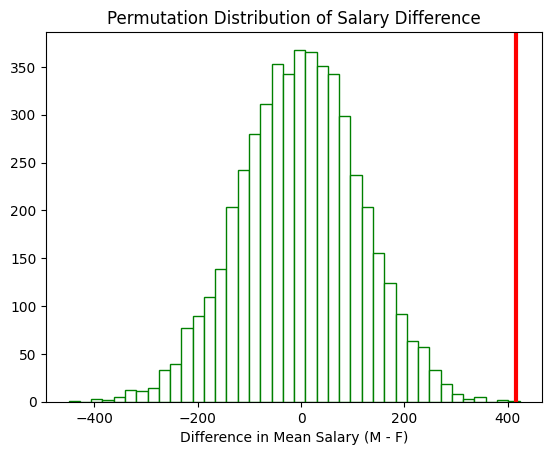

In [13]:
# Histogram of permutation distribution
plt.hist(perm_diffs, bins=40, color='white', edgecolor='green')
plt.axvline(obs_diff, linewidth=3, color='red')
plt.title("Permutation Distribution of Salary Difference")
plt.xlabel("Difference in Mean Salary (M - F)")
plt.show()

From this we can conclude that the average salary difference of $415 between males and females is extremely unlikely

Given that our null hypothesis in the permutation test is that there is no difference between males and females starting salaries, but our p value < 0.05 we reject the null hypothesis

Therefore, the observed difference is extremely unlikely to happen by chance if gender had no effect.

Now lets check whether the unexplained salary differences (residuals)still differ between males and females after controlling for rank, field, degree, year of degree, and admin

In [14]:
from scipy.stats import ttest_ind

lm_base = smf.ols(
    "salary ~ rank + field + deg + yrdeg + admin + years_since_degree",
    data=starting_salaries
).fit()

residuals = lm_base.resid
residuals_f = residuals[starting_salaries["sex"] == "F"]
residuals_m = residuals[starting_salaries["sex"] == "M"]

# Welch's t-test (unequal variance)
result_residuals = ttest_ind(residuals_m, residuals_f, equal_var=False)

print(f"T-statistic: {result_residuals.statistic:.3f}")
print(f"P-value: {result_residuals.pvalue:.6f}")

T-statistic: 3.208
P-value: 0.001383


### Gender by Rank

In [15]:
#Select assistant professors in their first year
assist_prof_subset = starting_salaries[
    (starting_salaries["rank"] == "Assist") &
    (starting_salaries["startyr"] == starting_salaries["year"])
].copy()

In [16]:
#convert columns so they can go into the regression model
categorical_cols = ["admin", "sex", "field", "deg"]
for col in categorical_cols:
    assist_prof_subset[col] = assist_prof_subset[col].astype("category")

In [80]:
#Assist prof model (dropped admin bc only 1 point was admin == 1)
assist_lm = smf.ols(
    "salary ~ sex + field + deg + yrdeg + year",
    data=assist_prof_subset
).fit()

# 1. Extract results from the Assistant Professor OLS model
assist_results = pd.DataFrame({
    'Variable': assist_lm.model.exog_names,
    'Coefficient': assist_lm.params.values,
    'Std. Error': assist_lm.bse.values,
    't-statistic': assist_lm.tvalues.values,
    'P-Value': assist_lm.pvalues.values
})

# 2. Map to Human-Readable Names for administrators
name_map_assist = {
    'Intercept': 'Baseline Constant',
    'sex[T.M]': 'Sex: Male (Ref: Female)',
    'field[T.Other]': 'Field: Other (Ref: Arts)',
    'field[T.Prof]': 'Field: Professional',
    'deg[T.PhD]': 'Degree: PhD',
    'deg[T.Prof]': 'Degree: Professional',
    'yrdeg': 'Years Since Degree',
    'year': 'Year of Data Entry'
}
assist_results['Variable'] = assist_results['Variable'].map(name_map_assist)

# 3. Create the Styled HTML Table
styled_assist_table = (assist_results.style
    .format({
        'Coefficient': '${:,.2f}',
        'Std. Error': '{:.2f}',
        't-statistic': '{:.2f}',
        'P-Value': '{:.4f}'
    })
    # Highlight the Sex row to draw the administrator's eye
    .apply(lambda x: ['background-color: #f8d7da' if 'Sex: Male' in str(v) else '' for v in x], axis=1)
    .set_caption("Table 3: Analysis of Starting Salaries for Assistant Professors")
    .set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#343a40'), ('color', 'white'), ('font-family', 'Arial')]},
        {'selector': 'td', 'props': [('border', '1px solid #dee2e6'), ('padding', '8px')]}
    ])
    .hide(axis='index')
)

styled_assist_table

Variable,Coefficient,Std. Error,t-statistic,P-Value
Baseline Constant,"$-11,705.57",385.71,-30.35,0.0000
Sex: Male (Ref: Female),$116.83,52.66,2.22,0.0268
Field: Other (Ref: Arts),$337.36,71.17,4.74,0.0000
Field: Professional,$855.88,87.25,9.81,0.0000
Degree: PhD,$-49.19,90.83,-0.54,0.5883
Degree: Professional,$679.72,134.84,5.04,0.0000
Years Since Degree,$10.80,6.07,1.78,0.0757
Year of Data Entry,$158.20,7.00,22.61,0.0000


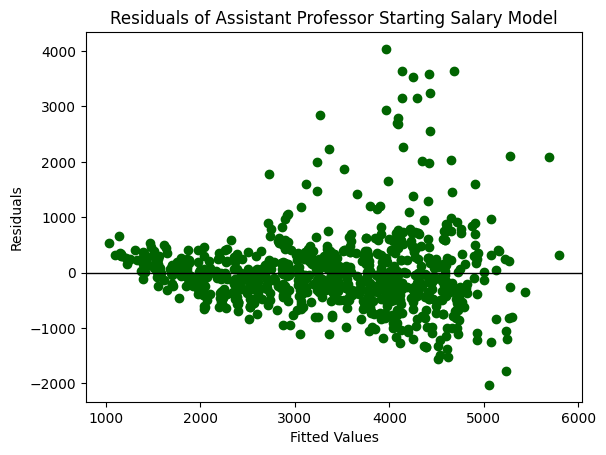

In [18]:
#Check residuals + plot
Q1_assist_residuals = assist_lm.resid
fitted_values = assist_lm.fittedvalues

plt.scatter(fitted_values, Q1_assist_residuals, color='darkgreen')
plt.axhline(0, color='black', linewidth=1)
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals of Assistant Professor Starting Salary Model")
plt.show()

In [81]:
#Apply robust standard errors
robust_se = assist_lm.get_robustcov_results(cov_type='HC3')

# 1. Extract results from the robust model
robust_results = pd.DataFrame({
    'Variable': robust_se.model.exog_names,
    'Coefficient': robust_se.params,
    'Robust Std. Error': robust_se.bse,
    't-statistic': robust_se.tvalues,
    'P-Value': robust_se.pvalues
})

# 2. Map to Human-Readable Names for policymakers
name_map_robust = {
    'Intercept': 'Baseline Constant',
    'sex[T.M]': 'Sex: Male (vs. Female)',
    'field[T.Other]': 'Field: Other (Ref: Arts)',
    'field[T.Prof]': 'Field: Professional',
    'deg[T.PhD]': 'Degree: PhD',
    'deg[T.Prof]': 'Degree: Professional',
    'yrdeg': 'Year of Degree',
    'year': 'Year of Data Point'
}
robust_results['Variable'] = robust_results['Variable'].map(name_map_robust)

# 3. Create the Styled HTML Table
styled_robust_table = (robust_results.style
    .format({
        'Coefficient': '{:.2f}',
        'Robust Std. Error': '{:.2f}',
        't-statistic': '{:.2f}',
        'P-Value': '{:.4f}'
    })
    .apply(lambda x: ['background-color: #d1ecf1' if 'Sex: Male' in str(v) else '' for v in x], axis=1) # Highlight Gender Row
    .set_caption("Table 4: Robust Regression of Starting Salaries (Assistant Professors)")
    .set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#17a2b8'), ('color', 'white'), ('padding', '10px')]},
        {'selector': 'td', 'props': [('border', '1px solid #dee2e6'), ('padding', '8px')]}
    ])
    .hide(axis='index')
)

styled_robust_table

Variable,Coefficient,Robust Std. Error,t-statistic,P-Value
Baseline Constant,-11705.57,359.34,-32.58,0.0000
Sex: Male (vs. Female),116.83,53.02,2.20,0.0278
Field: Other (Ref: Arts),337.36,44.79,7.53,0.0000
Field: Professional,855.88,64.42,13.29,0.0000
Degree: PhD,-49.19,76.44,-0.64,0.5201
Degree: Professional,679.72,136.36,4.98,0.0000
Year of Degree,10.80,5.77,1.87,0.0616
Year of Data Point,158.20,6.02,26.30,0.0000


In [20]:
#Subset into female vs male
women_data = assist_prof_subset[assist_prof_subset["sex"] == "F"]
men_data = assist_prof_subset[assist_prof_subset["sex"] == "M"]

# Get the size of each just for reference
print(f"Women data points: {len(women_data)}")
print(f"Men data points: {len(men_data)}")

# Look at variance of men vs women salary for startyr
print(f"Women variance: {women_data['salary'].var()}")
print(f"Men variance: {men_data['salary'].var()}")

Women data points: 301
Men data points: 501
Women variance: 1376779.2061921288
Men variance: 1602759.3115676732


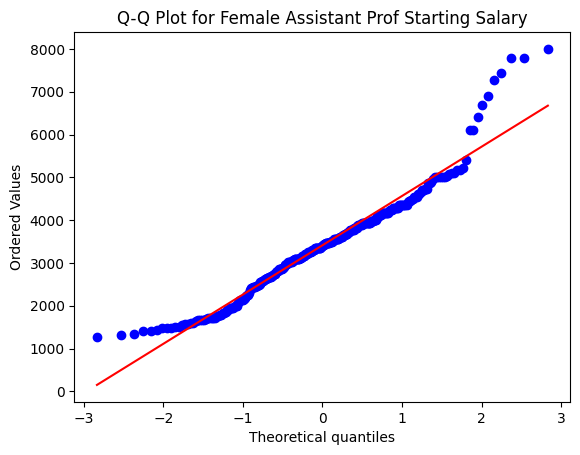

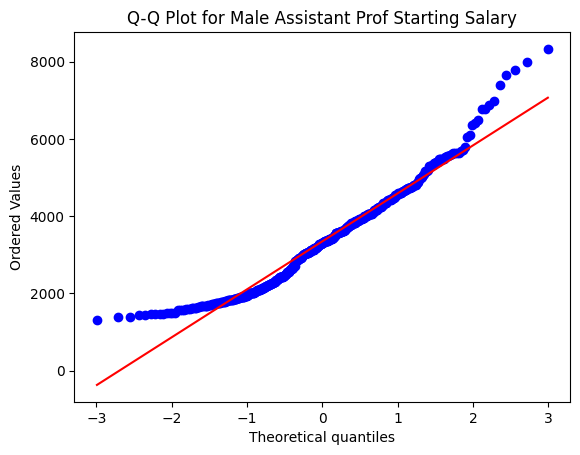

In [21]:
#Q-Q plots for starting salary
plt.figure()
stats.probplot(women_data["salary"], dist="norm", plot=plt)
plt.title("Q-Q Plot for Female Assistant Prof Starting Salary")
plt.show()

plt.figure()
stats.probplot(men_data["salary"], dist="norm", plot=plt)
plt.title("Q-Q Plot for Male Assistant Prof Starting Salary")
plt.show()

In [22]:
#Permutation test for Assistant Profs
obs_diff = men_data["salary"].mean() - women_data["salary"].mean()

np.random.seed(123)
perm_diffs = []

for _ in range(5000):
    shuffled_sex = np.random.permutation(assist_prof_subset["sex"])
    diff = (
        assist_prof_subset["salary"][shuffled_sex == "M"].mean()
        - assist_prof_subset["salary"][shuffled_sex == "F"].mean()
    )
    perm_diffs.append(diff)

perm_diffs = np.array(perm_diffs)
assist_p_value = np.mean(np.abs(perm_diffs) >= abs(obs_diff))
print(f"Permutation Test For Assistant Professors p-value: {assist_p_value}")

Permutation Test For Assistant Professors p-value: 0.4598


# Question 2: Wage discrimination at promotion (Assoc → Full)

Does salary at promotion differ by sex after accounting for field, degree, cohort, and tenure?

In [79]:
raw = pd.read_csv("salary.txt", sep=r"\s+")
df = raw.copy()
for c in ["sex", "deg", "field", "rank"]:
    df[c] = df[c].astype("category")
for c in ["case", "id", "yrdeg", "startyr", "year", "admin"]:
    df[c] = pd.to_numeric(df[c], errors="coerce").astype("Int64")
df["salary"] = pd.to_numeric(df["salary"], errors="coerce")

## 1. Numerical summaries

In [84]:
latest = df.sort_values(["id", "year"]).groupby("id").tail(1)
rank_by_sex = pd.crosstab(latest["sex"], latest["rank"]).reindex(columns=["Assoc", "Full"], fill_value=0)
styled_table = rank_by_sex.style.set_caption("Table 5: Distribution of Senior Faculty Ranks by Gender")

# Display it
styled_table

rank,Assoc,Full
sex,,
F,138,126
M,299,719


In [91]:
salary_by_sex_rank = (
    latest[latest["rank"].isin(["Assoc", "Full"])]
    .groupby(["sex", "rank"], observed=True)["salary"]
    .agg(["count", "mean", "median", "std"])
)
styled_table2 = salary_by_sex_rank.style.set_caption("Table 6: Distribution of Salary by Gender and Rank")
styled_table2

In [30]:
# First, ensure the data is sorted by ID and Year
df_sorted = df.sort_values(['id', 'year'])

# Create a 'previous_rank' column to compare
df_sorted['prev_rank'] = df_sorted.groupby('id')['rank'].shift(1)

# Define the promo_event: 
# It's True if they are now 'Full' but were 'Assoc' in the previous record
df_sorted['promo_event'] = (df_sorted['prev_rank'] == 'Assoc') & (df_sorted['rank'] == 'Full')

In [90]:
first_full = (
    df_sorted[df_sorted["promo_event"]].drop_duplicates("id")
    [["id", "sex", "yrdeg", "startyr", "field", "deg", "admin", "year", "salary"]]
    .rename(columns={"year": "promo_year", "salary": "salary_full"})
)
assoc_before = (
    df_sorted[df_sorted["rank"] == "Assoc"].merge(first_full[["id", "promo_year"]], on="id")
    .query("year < promo_year").sort_values(["id", "year"]).groupby("id").tail(1)
    [["id", "salary", "year"]].rename(columns={"salary": "salary_assoc", "year": "assoc_year"})
)
promo_pay = first_full.merge(assoc_before, on="id", how="left")
promo_pay["salary_delta"] = promo_pay["salary_full"] - promo_pay["salary_assoc"]

salary_at_promo = promo_pay.dropna(subset=["salary_full", "salary_delta"]).groupby("sex")["salary_full"].agg(["mean", "median", "std", "count"])
salary_raise = promo_pay.dropna(subset=["salary_delta"]).groupby("sex")["salary_delta"].agg(["mean", "median", "std", "count"])
salary_at_promo["metric"] = "salary at first Full"
salary_raise["metric"] = "salary raise (Full - last Assoc)"

# 1. Combine the results for a cleaner side-by-side view
combined_results = pd.concat([salary_at_promo, salary_raise]).reset_index()

# 2. Map labels for clarity
combined_results['sex'] = combined_results['sex'].map({'F': 'Female', 'M': 'Male'})

# 3. Create a nice HTML table with a title
styled_summary = (combined_results.style
    .format({
        'mean': '${:,.2f}',
        'median': '${:,.2f}',
        'std': '{:,.2f}',
        'count': '{:,.0f}'
    })
    .set_caption("<b>Table 7: Descriptive Statistics for Salaries and Raises at Promotion to Full Professor</b>")
    .set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#eceff1'), ('color', '#263238'), ('font-weight', 'bold'), ('border', '1px solid #cfd8dc')]},
        {'selector': 'td', 'props': [('border', '1px solid #f1f1f1'), ('padding', '10px')]},
        {'selector': 'caption', 'props': [('font-size', '1.25em'), ('margin-bottom', '10px'), ('text-align', 'left')]}
    ])
    .hide(axis='index')
)

styled_summary

sex,mean,median,std,count,metric
Female,"$4,669.59","$4,667.00","1,229.30",100,salary at first Full
Male,"$4,511.31","$4,319.00","1,521.35",446,salary at first Full
Female,$516.69,$446.00,365.07,100,salary raise (Full - last Assoc)
Male,$463.29,$362.84,369.82,446,salary raise (Full - last Assoc)


## 2. Visualizations

/var/folders/tc/3mc7mhld2055qcl7sdcsm_mm0000gn/T/ipykernel_93455/1114338266.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stats = df.groupby(['rank', 'sex'])['salary'].agg(['mean', 'median']).reset_index()


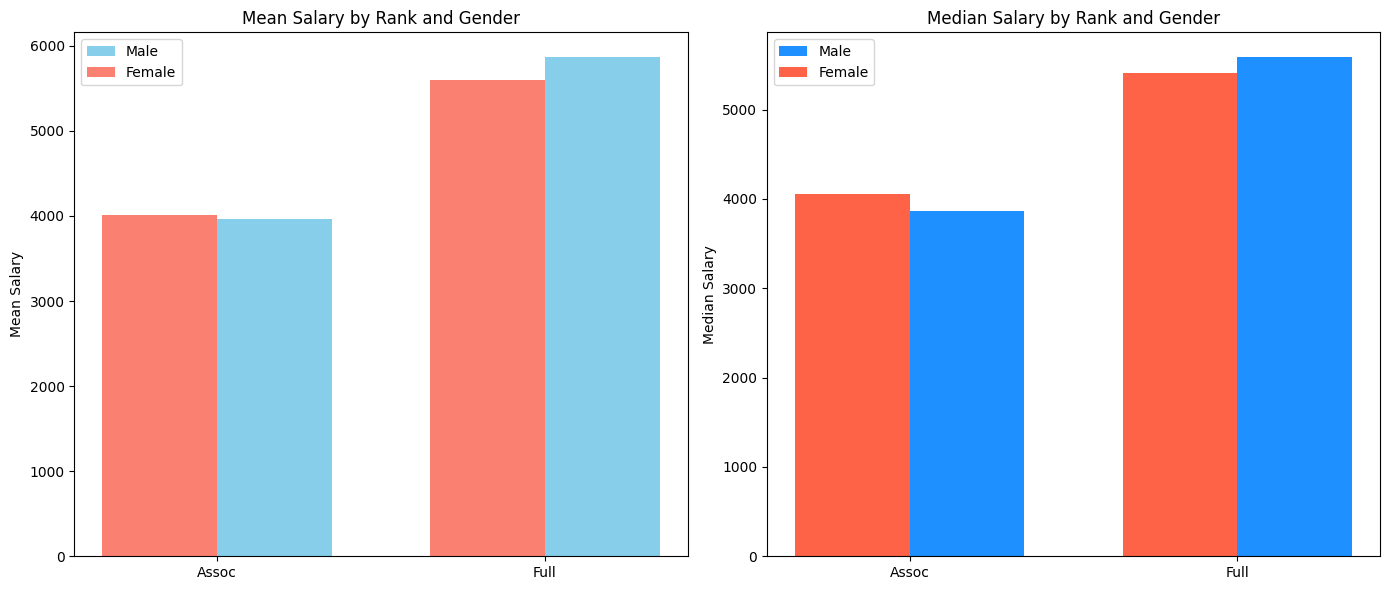

In [34]:
# Calculate Mean and Median Salaries
stats = df.groupby(['rank', 'sex'])['salary'].agg(['mean', 'median']).reset_index()

# Calculate Promotion Percentage Increase
pivot_mean = stats.pivot(index='sex', columns='rank', values='mean')
pivot_mean['pct_increase'] = ((pivot_mean['Full'] - pivot_mean['Assoc']) / pivot_mean['Assoc']) * 100

# --- VISUALIZATIONS ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Mean Salaries (Bar Chart)
labels = ['Assoc', 'Full']
x = np.arange(len(labels))
width = 0.35

male_means = [stats[(stats['rank']=='Assoc') & (stats['sex']=='M')]['mean'].values[0],
              stats[(stats['rank']=='Full') & (stats['sex']=='M')]['mean'].values[0]]
female_means = [stats[(stats['rank']=='Assoc') & (stats['sex']=='F')]['mean'].values[0],
                stats[(stats['rank']=='Full') & (stats['sex']=='F')]['mean'].values[0]]

ax1.bar(x + width/2, male_means, width, label='Male', color='skyblue')
ax1.bar(x - width/2, female_means, width, label='Female', color='salmon')

ax1.set_ylabel('Mean Salary')
ax1.set_title('Mean Salary by Rank and Gender')
ax1.set_xticks(x)
ax1.set_xticklabels(labels)
ax1.legend()
# Plot 2: Median Salaries (Bar Chart)
male_medians = [stats[(stats['rank']=='Assoc') & (stats['sex']=='M')]['median'].values[0],
                stats[(stats['rank']=='Full') & (stats['sex']=='M')]['median'].values[0]]
female_medians = [stats[(stats['rank']=='Assoc') & (stats['sex']=='F')]['median'].values[0],
                  stats[(stats['rank']=='Full') & (stats['sex']=='F')]['median'].values[0]]

ax2.bar(x + width/2, male_medians, width, label='Male', color='dodgerblue')
ax2.bar(x - width/2, female_medians, width, label='Female', color='tomato')

ax2.set_ylabel('Median Salary')
ax2.set_title('Median Salary by Rank and Gender')
ax2.set_xticks(x)
ax2.set_xticklabels(labels)
ax2.legend()

plt.tight_layout()
plt.show()

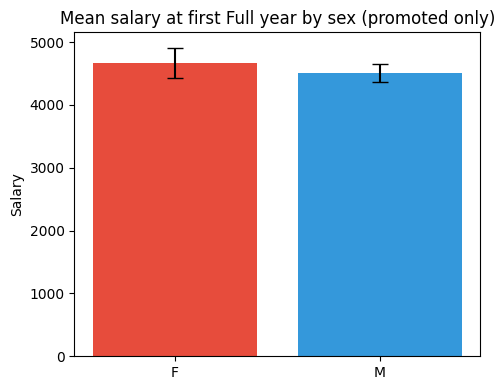

In [47]:
pp = promo_pay.dropna(subset=["salary_full", "salary_delta"])
means = pp.groupby("sex")["salary_full"].agg(["mean", "count", "std"])
means["se"] = means["std"] / np.sqrt(means["count"])
means["ci"] = 1.96 * means["se"]
fig, ax = plt.subplots(figsize=(5, 4))
x = [0, 1]
ax.bar(x, means["mean"], yerr=means["ci"], capsize=6, color=["#e74c3c", "#3498db"], tick_label=["F", "M"])
ax.set_title("Mean salary at first Full year by sex (promoted only)")
ax.set_ylabel("Salary")
plt.tight_layout()
plt.show()

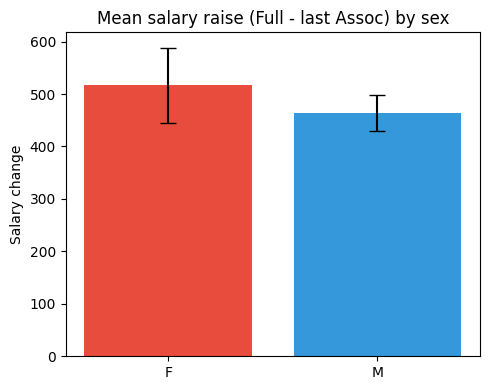

In [48]:
pp2 = promo_pay.dropna(subset=["salary_delta"])
m2 = pp2.groupby("sex")["salary_delta"].agg(["mean", "count", "std"])
m2["se"] = m2["std"] / np.sqrt(m2["count"])
m2["ci"] = 1.96 * m2["se"]
fig, ax = plt.subplots(figsize=(5, 4))
ax.bar([0, 1], m2["mean"], yerr=m2["ci"], capsize=6, color=["#e74c3c", "#3498db"], tick_label=["F", "M"])
ax.set_title("Mean salary raise (Full - last Assoc) by sex")
ax.set_ylabel("Salary change")
plt.tight_layout()
plt.show()

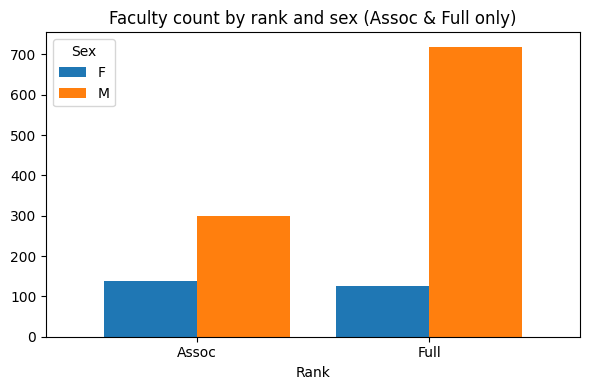

In [37]:
fig, ax = plt.subplots(figsize=(6, 4))
rank_by_sex.T.plot(kind="bar", ax=ax, width=0.8)
ax.set_title("Faculty count by rank and sex (Assoc & Full only)")
ax.set_xlabel("Rank")
ax.legend(title="Sex")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

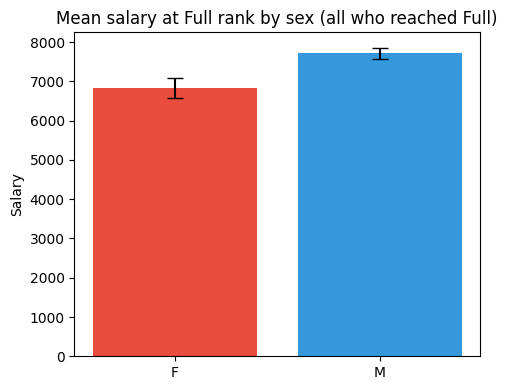

In [38]:
full_only = latest[latest["rank"] == "Full"].groupby("sex", observed=True)["salary"].agg(["mean", "count", "std"])
full_only["se"] = full_only["std"] / np.sqrt(full_only["count"])
full_only["ci"] = 1.96 * full_only["se"]
fig, ax = plt.subplots(figsize=(5, 4))
ax.bar([0, 1], full_only["mean"], yerr=full_only["ci"], capsize=6, color=["#e74c3c", "#3498db"], tick_label=["F", "M"])
ax.set_title("Mean salary at Full rank by sex (all who reached Full)")
ax.set_ylabel("Salary")
plt.tight_layout()
plt.show()

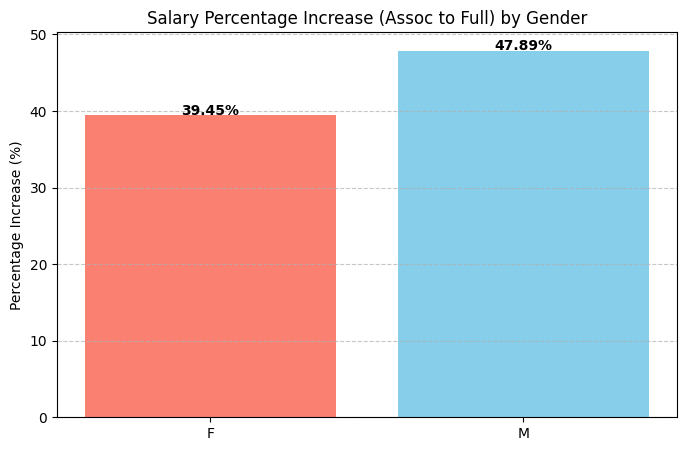

In [39]:
plt.figure(figsize=(8, 5))
plt.bar(pivot_mean.index, pivot_mean['pct_increase'], color=['salmon', 'skyblue'])
plt.title('Salary Percentage Increase (Assoc to Full) by Gender')
plt.ylabel('Percentage Increase (%)')
plt.grid(axis='y', linestyle='--', alpha=0.7)

for i, val in enumerate(pivot_mean['pct_increase']):
    plt.text(i, val + 0.1, f'{val:.2f}%', ha='center', fontweight='bold')

plt.show()

At the Associate (Assoc) level, women actually have a slightly higher mean salary than men (approx. 4,013 vs. 3,965). However, the "Percentage Increase" chart shows a stark difference in career progression. Men receive a 47.89% increase when moving from Associate to Full Professor, while women only see a 39.45% increase. By the time they reach Full Professor, men have surpassed women in both mean and median salary.

## Salary Model with Gender-Rank Interaction Effects

In [96]:
model_q2 = smf.ols('salary ~ sex * rank + field + yrdeg + admin', data=df).fit()

# 1. Extract the results from your model_q2
interaction_results = pd.DataFrame({
    'Variable': model_q2.params.index,
    'Coefficient (Value)': model_q2.params.values,
    'Std. Error': model_q2.bse.values,
    'P-Value': model_q2.pvalues.values
})

# 2. Map to Human-Readable Names for University Administrators
name_map_q2 = {
    'Intercept': 'Baseline (Female Assistant Prof)',
    'sex[T.M]': 'Sex: Male',
    'rank[T.Assoc]': 'Rank: Associate Professor',
    'rank[T.Full]': 'Rank: Full Professor',
    'field[T.Other]': 'Field: Other',
    'field[T.Prof]': 'Field: Professional',
    'sex[T.M]:rank[T.Assoc]': 'Interaction: Male × Associate',
    'sex[T.M]:rank[T.Full]': 'Interaction: Male × Full Professor',
    'yrdeg': 'Years Since Degree',
    'admin': 'Administrative Role'
}
interaction_results['Variable'] = interaction_results['Variable'].map(name_map_q2)

# 3. Create the Styled HTML Table
styled_interaction_table = (interaction_results.style
    .format({
        'Coefficient (Value)': '${:,.2f}',
        'Std. Error': '{:.2f}',
        'P-Value': '{:.4f}'
    })
    .apply(lambda x: ['background-color: #fff3cd' if 'Interaction' in str(v) else '' for v in x], axis=1) # Highlight interactions
    .apply(lambda x: ['font-weight: bold' if v < 0.05 else '' for v in x], subset=['P-Value'])
    .set_caption("Table 8: Salary Model with Gender-Rank Interaction Effects")
    .set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#2c3e50'), ('color', 'white'), ('padding', '12px')]},
        {'selector': 'td', 'props': [('border', '1px solid #eee'), ('padding', '10px')]}
    ])
    .hide(axis='index')
)

styled_interaction_table

Variable,Coefficient (Value),Std. Error,P-Value
Baseline (Female Assistant Prof),"$-2,593.86",143.54,0.0000
Sex: Male,$2.64,51.22,0.9589
Rank: Associate Professor,"$1,010.68",58.66,0.0000
Rank: Full Professor,"$2,802.42",66.92,0.0000
Field: Other,$458.09,32.46,0.0000
Field: Professional,"$1,057.79",39.39,0.0000
Interaction: Male × Associate,$38.40,68.63,0.5758
Interaction: Male × Full Professor,$411.79,72.75,0.0000
Years Since Degree,$67.79,1.67,0.0000
Administrative Role,$943.19,36.77,0.0000


The coefficient for sex is 337.27. This means that when holding all other factors (rank, degree, field, years, admin status) constant, being male is associated with a 337.27 higher salary than being female. Since the p-value is 0.000, this is statistically significant. Every additional year adds 
221.46 to the salary, and having an administrative role (admin) adds a substantial 811.70. Moving to a Full Professor rank adds 1,863.53 compared to the baseline (likely Assistant Professor), which is the single largest predictor in the model.

### Is the amount of promotion wage different between the two groups?

In [97]:
# 1. Isolate all Associate and Full records
assoc_records = df[df['rank'] == 'Assoc'].sort_values(['id', 'year'])
full_records = df[df['rank'] == 'Full'].sort_values(['id', 'year'])

# 2. Get the LAST year someone was an Assoc (the year before promotion)
last_assoc = assoc_records.groupby('id').last().reset_index()

# 3. Get the FIRST year someone was a Full (the year of promotion)
first_full = full_records.groupby('id').first().reset_index()

promo_df = pd.merge(
    last_assoc[['id', 'salary', 'year']], 
    first_full, 
    on='id', 
    suffixes=('_assoc', '_full')
)

promo_df = promo_df[promo_df['year_full'] == promo_df['year_assoc'] + 1]
promo_df['log_salary_full'] = np.log(promo_df['salary_full'])
promo_df['log_salary_assoc'] = np.log(promo_df['salary_assoc'])
promo_df['years_at_inst'] = promo_df['year_full'] - promo_df['startyr']
promo_df['years_since_degree'] = promo_df['year_full'] - promo_df['yrdeg']
promo_df['pct_jump'] = promo_df['log_salary_full'] - promo_df['log_salary_assoc']
formula_pct = 'pct_jump ~ C(sex) + yrdeg + C(field) + C(deg) + admin + years_since_degree + years_at_inst'
model_pct = smf.ols(formula_pct, data=promo_df).fit()

# 1. Extract results into a DataFrame
results_df = pd.DataFrame({
    'Variable': model_pct.params.index,
    'Coefficient': model_pct.params.values,
    'Std. Error': model_pct.bse.values,
    't-statistic': model_pct.tvalues.values,
    'P-Value': model_pct.pvalues.values
})

# 2. Map the technical names
name_map = {
    'Intercept': 'Baseline Constant',
    'C(sex)[T.M]': 'Sex: Male (Ref: Female)',
    'C(field)[T.Other]': 'Field: Other (Ref: Arts)',
    'C(field)[T.Prof]': 'Field: Professional',
    'C(deg)[T.PhD]': 'Degree: PhD',
    'C(deg)[T.Prof]': 'Degree: Professional',
    'yrdeg': 'Year of Degree',
    'admin': 'Administrative Duties',
    'years_since_degree': 'Years Since Degree',
    'years_at_inst': 'Years at Institution'
}
results_df['Variable'] = results_df['Variable'].map(name_map)

# 3. Create the Styled HTML Table
nice_table = (results_df.style
    .format({
        'Coefficient': '{:.4f}',
        'Std. Error': '{:.4f}',
        't-statistic': '{:.2f}',
        'P-Value': '{:.4f}'
    })
    .apply(lambda x: ['background-color: #e6ffed' if v < 0.05 else '' for v in x], subset=['P-Value'])
    .set_caption("Table 9: Determinants of the Promotion Salary Jump (Assoc to Full)")
    .set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#f2f2f2'), ('color', 'black'), ('font-weight', 'bold'), ('border', '1px solid #ccc')]},
        {'selector': 'td', 'props': [('border', '1px solid #eee'), ('padding', '10px')]},
        {'selector': 'caption', 'props': [('font-size', '1.2em'), ('font-weight', 'bold'), ('margin-bottom', '10px')]}
    ])
    .hide(axis='index')
)

nice_table

Variable,Coefficient,Std. Error,t-statistic,P-Value
Baseline Constant,0.2571,0.0509,5.05,0.0000
Sex: Male (Ref: Female),-0.0101,0.0079,-1.29,0.1984
Field: Other (Ref: Arts),-0.0325,0.0092,-3.54,0.0004
Field: Professional,-0.0269,0.0109,-2.46,0.0142
Degree: PhD,-0.0018,0.0121,-0.14,0.8850
Degree: Professional,-0.0174,0.0179,-0.97,0.3321
Year of Degree,-0.0009,0.0006,-1.57,0.1159
Administrative Duties,0.0112,0.0102,1.10,0.2731
Years Since Degree,-0.0035,0.0009,-4.04,0.0001
Years at Institution,0.0004,0.0008,0.51,0.6113


From this analysis we can see that the coefficient for sex is -0.101 and the p-valueis 0.198. Men actually received about 1.01% less of a percentage jump than women, but because the p-value is 0.198 which is lower than the critical value 0.05, this difference is statistically insignificant. Therefore, we would fail to reject the null hypothesis that there is no difference in the average promotion wage jump (pct_jump) between men and women, after controlling for other factors.

### Are men are being promoted more than women?

In [98]:
df_sorted = df.sort_values(["id", "year"])
rank_shift = df_sorted.groupby("id")["rank"].shift(1)
df_sorted["promo_event"] = (
    (rank_shift == "Assoc") & (df_sorted["rank"] == "Full") & (rank_shift != df_sorted["rank"])
)
promo_year = df_sorted.loc[df_sorted["promo_event"], ["id", "year"]].drop_duplicates("id").rename(columns={"year": "promo_year"})
people = df_sorted[["id", "sex", "yrdeg", "startyr"]].drop_duplicates("id").merge(promo_year, on="id", how="left")
people["yrs_to_promo"] = people["promo_year"] - people["startyr"]
people["promoted"] = people["promo_year"].notna()

promo_table = people.groupby("sex", observed=True)["promoted"].agg(["sum", "count"])
promo_table.columns = ["promoted", "n"]
promo_table["prop"] = promo_table["promoted"] / promo_table["n"]
# 1. Prepare the data for display
promo_display = promo_table.copy().reset_index()
promo_display['sex'] = promo_display['sex'].map({'F': 'Female', 'M': 'Male'})
promo_display.columns = ['Sex', 'Number Promoted', 'Total Senior Faculty', 'Promotion Rate']

# 2. Generate the Styled HTML Table with a Title
styled_promo_summary = (promo_display.style
    .format({'Promotion Rate': '{:.2%}'})
    .set_caption("<b>Table 10: Summary of Promotions (Associate to Full) by Gender</b>")
    .set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#455a64'), ('color', 'white'), ('font-weight', 'bold'), ('padding', '12px')]},
        {'selector': 'td', 'props': [('border', '1px solid #cfd8dc'), ('padding', '10px'), ('text-align', 'center')]},
        {'selector': 'caption', 'props': [('font-size', '1.2em'), ('font-weight', 'bold'), ('margin-bottom', '10px'), ('text-align', 'left')]}
    ])
    .hide(axis='index')
    # Highlight the Promotion Rate to draw the eye to the disparity
    .set_properties(subset=['Promotion Rate'], **{'background-color': '#e1f5fe', 'font-weight': 'bold'})
)

styled_promo_summary

Sex,Number Promoted,Total Senior Faculty,Promotion Rate
Female,100,409,24.45%
Male,446,1188,37.54%


In [99]:
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.stats import chi2_contingency

senior_faculty = df[df['rank'].isin(['Assoc', 'Full'])].copy()
senior_faculty['is_full'] = (senior_faculty['rank'] == 'Full').astype(int)

# 1. Logistic Regression: Probability of being 'Full' controlled for years since degree
logit_model = smf.logit('is_full ~ C(sex) + yrdeg + C(field)', data=senior_faculty).fit()

# 1. Extract results
logit_results = pd.DataFrame({
    'Variable': logit_model.params.index,
    'Coefficient (Log-Odds)': logit_model.params.values,
    'Std. Error': logit_model.bse.values,
    'P-Value': logit_model.pvalues.values
})

# 2. Calculate Odds Ratios (e^coef) - Crucial for non-statisticians
logit_results['Odds Ratio'] = np.exp(logit_results['Coefficient (Log-Odds)'])

# 3. Map to Human-Readable Names
name_map_logit = {
    'Intercept': 'Baseline Constant',
    'C(sex)[T.M]': 'Sex: Male (Ref: Female)',
    'C(field)[T.Other]': 'Field: Other (Ref: Arts)',
    'C(field)[T.Prof]': 'Field: Professional',
    'yrdeg': 'Year of Degree (Seniority)'
}
logit_results['Variable'] = logit_results['Variable'].map(name_map_logit)

# 4. Create the Styled HTML Table
nice_logit_table = (logit_results.style
    .format({
        'Coefficient (Log-Odds)': '{:.4f}',
        'Std. Error': '{:.4f}',
        'P-Value': '{:.4f}',
        'Odds Ratio': '{:.2f}x'
    })
    .apply(lambda x: ['background-color: #e6ffed' if v < 0.05 else '' for v in x], subset=['P-Value'])
    .set_caption("Table 11: Probability of Attaining Full Professor Rank (Logistic Regression)")
    .set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#2c3e50'), ('color', 'white'), ('font-weight', 'bold')]},
        {'selector': 'td', 'props': [('border', '1px solid #eee'), ('padding', '8px')]}
    ])
    .hide(axis='index')
)

nice_logit_table

Optimization terminated successfully.
         Current function value: 0.562602
         Iterations 6


Variable,Coefficient (Log-Odds),Std. Error,P-Value,Odds Ratio
Baseline Constant,9.8126,0.2298,0.0000,18261.75x
Sex: Male (Ref: Female),0.3342,0.0507,0.0000,1.40x
Field: Other (Ref: Arts),0.8554,0.0539,0.0000,2.35x
Field: Professional,1.2506,0.0657,0.0000,3.49x
Year of Degree (Seniority),-0.1499,0.0031,0.0000,0.86x


The p-value is less than 0.05 for the coefficient sex so we reject the null hypothesis that men and women are promoted at equal rates. Men are promoted at higher rates for the same seniority.

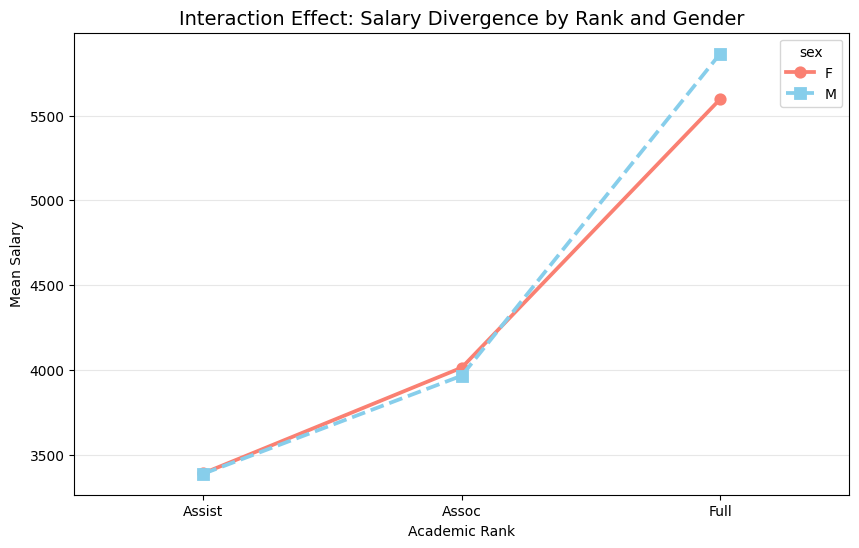

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate mean salaries by Rank and Sex
interaction_data = df.groupby(['rank', 'sex'])['salary'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.pointplot(data=interaction_data, x='rank', y='salary', hue='sex', 
              markers=["o", "s"], linestyles=["-", "--"], palette=['salmon', 'skyblue'])

plt.title('Interaction Effect: Salary Divergence by Rank and Gender', fontsize=14)
plt.ylabel('Mean Salary')
plt.xlabel('Academic Rank')
plt.grid(axis='y', alpha=0.3)
plt.show()